# Apo reconstruction with iterative methods

Notebook from Stephanie Ribet and Georgios Varnavides

Data from B Küçükoğlu et al, Low-dose cryo-electron ptychography of proteins at sub-nanometer resolution, Nature Communications (2025).

In [2]:
import numpy as np
import quantem as em
import matplotlib.pyplot as plt

em.core.config.set_device(1)
print(em.__version__)

0.1.8


# load data

In [4]:
# Data can be downloaded from https://doi.org/10.5281/zenodo.18449974
dc = em.io.load("data/apo_arina_calibrated.zip")
dc

Dataset(shape=(128, 128, 128, 128), dtype=float32, name='4D-STEM dataset')
  sampling: [20.         20.          0.10225094  0.10225094]
  units: ['A', 'A', 'mrad', 'mrad']
  signal units: 'arb. units'

In [5]:
# calibrations
PROBE_SEMIANGLE = 4
ENERGY = 300e3

# iterative ptycho

In [6]:
pdset = em.diffractive_imaging.PtychographyDatasetRaster.from_dataset4dstem(dc)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=False,
    plot_com=False,
    probe_energy=ENERGY,
    force_com_rotation=-90,
    force_com_transpose = False,
)

Forcing best fit rotation to -90 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/16384 [00:00<?, ?probe position/s]

In [7]:
ptycho_pix = em.diffractive_imaging.PtychoLite.from_dataset(
    dset=pdset,
    num_slices=1,
    obj_type="pure_phase",
    num_probes=1,
    energy=ENERGY,
    semiangle_cutoff=PROBE_SEMIANGLE,
    obj_padding_px=(48,48),
    device="cpu",
    polar_parameters = {'C10': 13700}
)

In [8]:
ptycho_pix=ptycho_pix.reconstruct(
    num_iters=100, 
    device=em.core.config.get_device(), 
    batch_size=1024,
    reset = True,
)

  0%|          | 0/100 [00:00<?, ?it/s]

# dip

In [ ]:
ptycho_dip = em.diffractive_imaging.PtychoLiteDIP.from_ptycholite(
    ptycholite=ptycho_pix,
    pretrain_iters=150,
    device=em.core.config.get_device(),
    verbose=False,
)

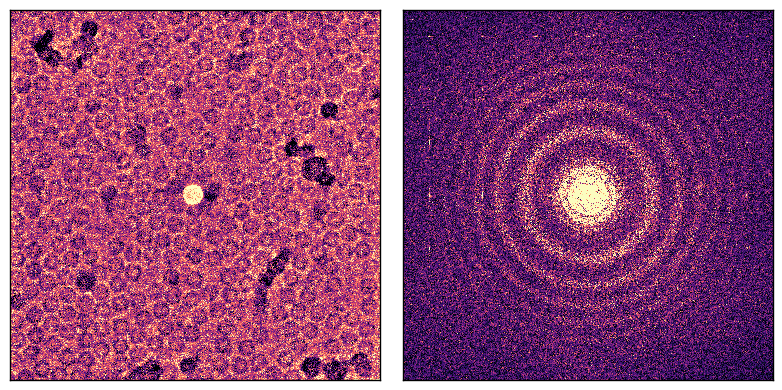

In [13]:
def fft(array):
    return np.abs(np.fft.fftshift(np.fft.fft2(array)))

norm = em.visualization.NormalizationConfig(
    lower_quantile=0.3,
    upper_quantile=0.99
)

crop = 40
crop_2 = 400

em.visualization.show_2d(
    [
        np.angle(ptycho_dip.obj_cropped[0])[crop:-crop,crop:-crop],
        fft(np.angle(ptycho_dip.obj_cropped[0]))[crop_2:-crop_2,crop_2:-crop_2]
    ],
    cmap = "magma",
    axsize = (4,4),
);